# Предсказание вторичной структуры белков на основе аминокислотной последовательности с использованием методов машинного обучения

In [ ]:
!pip install biopython scikit-learn seaborn transformers torch xgboost

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from transformers import AutoTokenizer, AutoModel
import torch
import random
import xgboost as xgb

In [ ]:
# Загрузка и первичная обработка данных
df = pd.read_csv("/content/drive/MyDrive/ColabFiles/biotech_project/train.csv")
df = df[['seq', 'sst3']].dropna()
print("Размер датасета:", df.shape)


Размер датасета: (5534, 2)


In [ ]:
# Вычисление физико-химических признаков белков
def protein_features(sequence):
    try:
        analysis = ProteinAnalysis(sequence)
        return [
            analysis.molecular_weight(),
            analysis.aromaticity(),
            analysis.instability_index(),
            analysis.gravy(),
            analysis.isoelectric_point()
        ]
    except:
        return [np.nan]*5

features = df['seq'].apply(protein_features)
features_df = pd.DataFrame(features.tolist(),
                           columns=['molecular_weight','aromaticity','instability_index','gravy','isoelectric_point'])
df = pd.concat([df, features_df], axis=1)
df = df.dropna()


In [ ]:
# Создание целевой переменной 'target'
def get_dominant_ss_from_sst3(sst_sequence):
    if not isinstance(sst_sequence, str) or not sst_sequence:
        return np.nan
    valid_chars = [char for char in sst_sequence if char in ['C', 'H', 'E']]
    if not valid_chars:
        return np.nan
    counts = Counter(valid_chars)
    return max(counts, key=counts.get)

df['target'] = df['sst3'].apply(get_dominant_ss_from_sst3)
df.dropna(subset=['target'], inplace=True)
df.head()

,seq,sst3,molecular_weight,aromaticity,instability_index,gravy,isoelectric_point,target
1,RPESELIRQSWRVVSRSPLEHGTVLFARLFALEPSLLPLFQYNGRQ...,CCCHHHHHHHHHHHHCCHHHHHHHHHHHHHHHCHHHHHHCCECCEC...,16615.7038,0.094595,55.892568,-0.137162,6.348825,H
2,MKIAILGAGCYRTHAAAGITNFMRACEVAKEVGKPEIALTHSSITY...,CEEEEECCCCCHHHHHHCCCCCHHHHHHHHHHCCHHHHHCCHHHHH...,37066.8496,0.052326,28.167151,0.056686,5.473618,H
3,RRTVPRGTLRKIIKKHKPHLRLAANTDLLVHLSFLLFLHRLAEEAR...,CCCCCHHHHHHHHHHHCCCCCCCCCHHHHHHHHHHHHHHHHHHHHH...,8628.2536,0.040000,24.972000,-0.306667,11.341552,H
7,LLHKRVVLASASPRRQEILSNAGLRFEVVPSKFKEKLDKASFATPY...,CCCCCEEECCCCHHHHHHHHHCCCCCEECCCCCCCCCCHHHCCCHH...,22849.9723,0.093137,33.626520,-0.189216,7.217836,H
10,KLHEIKQELKDLFSHLPYKINKVEVSLYEPGVLLIDIDGEDSALLI...,CHHHHHHHHHHHCCCCCCCEEEEEEEEEECCEEEEEEEEHHHCCCC...,16763.3276,0.103448,20.722069,-0.212414,8.635427,H


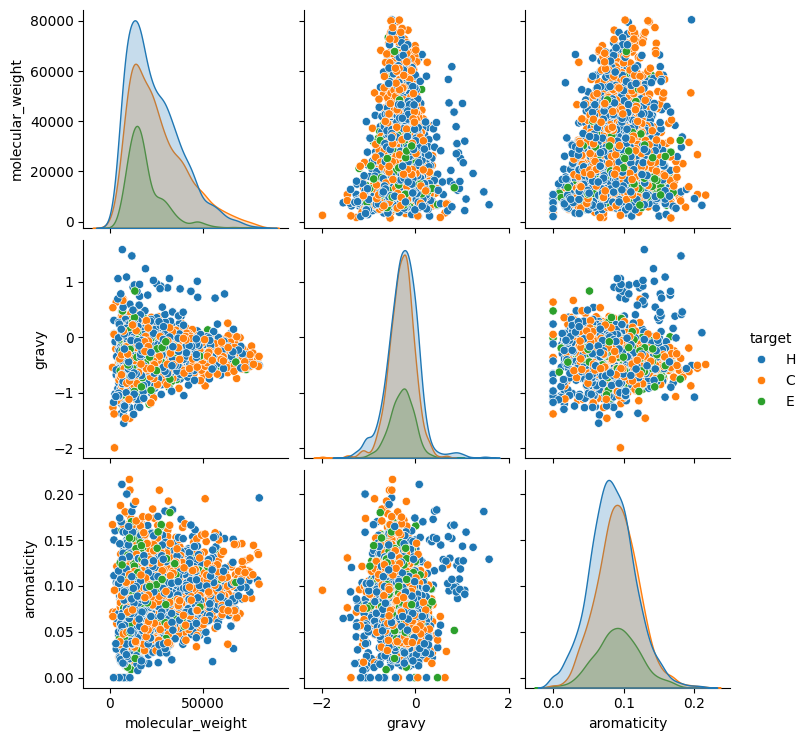

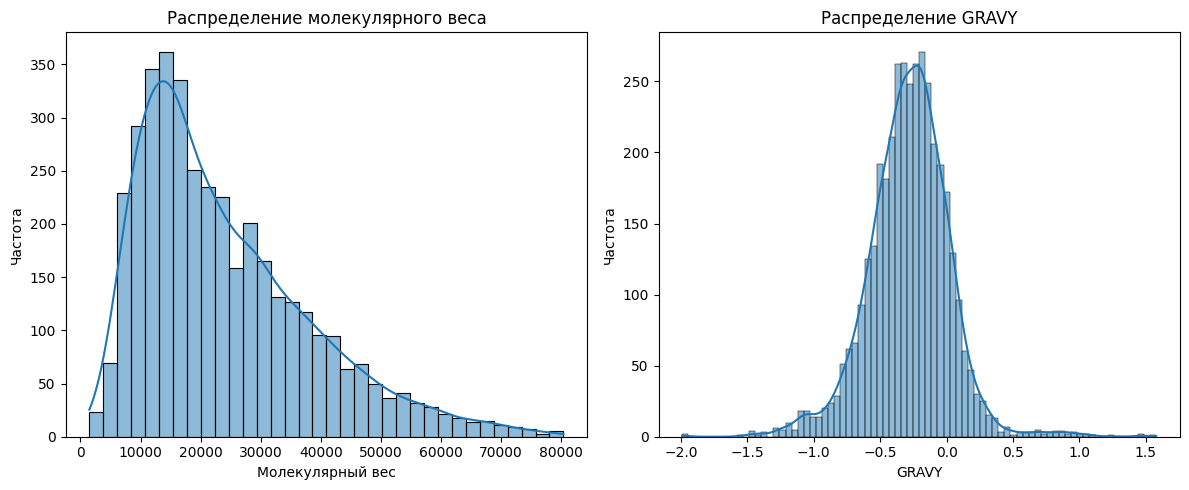

In [ ]:
# Визуализация признаков
sns.pairplot(df[['molecular_weight','gravy','aromaticity','target']], hue='target')
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['molecular_weight'], kde=True)
plt.title('Распределение молекулярного веса')
plt.xlabel('Молекулярный вес')
plt.ylabel('Частота')
plt.subplot(1, 2, 2)
sns.histplot(df['gravy'], kde=True)
plt.title('Распределение GRAVY')
plt.xlabel('GRAVY')
plt.ylabel('Частота')
plt.tight_layout()
plt.show()

Feature-based RandomForest:
              precision    recall  f1-score   support

           C       0.50      0.47      0.49       302
           E       0.40      0.13      0.20       105
           H       0.58      0.72      0.64       369

    accuracy                           0.54       776
   macro avg       0.49      0.44      0.44       776
weighted avg       0.52      0.54      0.52       776



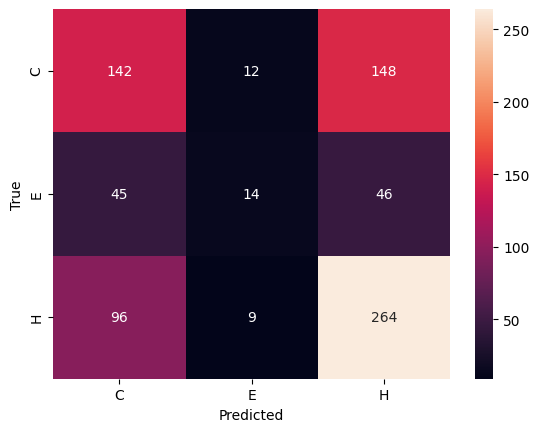

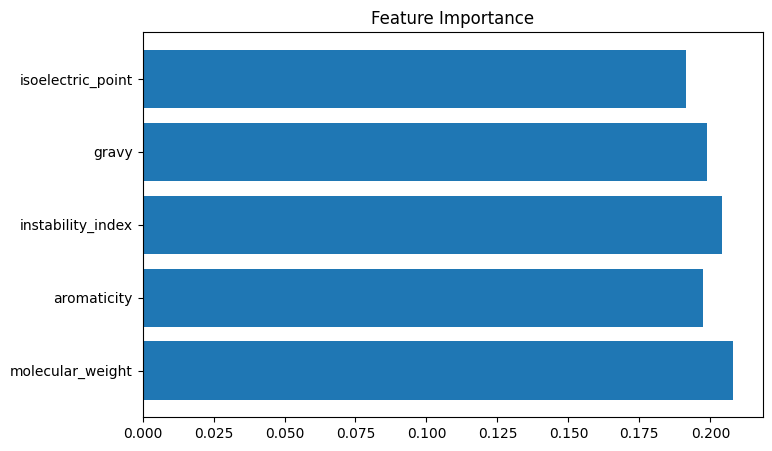

In [ ]:
feature_columns = ['molecular_weight','aromaticity','instability_index','gravy','isoelectric_point']
X = df[feature_columns]
y = df['target']
X_train_feat, X_test_feat, y_train_feat, y_test_feat = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train_feat, y_train_feat)
pred_feat = model.predict(X_test_feat)
print("Feature-based RandomForest:")
print(classification_report(y_test_feat, pred_feat))

# Confusion Matrix
cm = confusion_matrix(y_test_feat, pred_feat)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Feature Importance
importance = model.feature_importances_
plt.figure(figsize=(8,5))
plt.barh(feature_columns, importance)
plt.title("Feature Importance")
plt.show()

In [ ]:
# Моделирование мутаций
amino_acids = "ACDEFGHIKLMNPQRSTVWY"
def mutate(sequence):
    pos = random.randint(0, len(sequence)-1)
    new_aa = random.choice(amino_acids)
    return sequence[:pos] + new_aa + sequence[pos+1:]

original_seq = df.iloc[0]['seq']
mutated_seq = mutate(original_seq)
orig_features = protein_features(original_seq)
mut_features = protein_features(mutated_seq)

orig_df = pd.DataFrame([orig_features], columns=feature_columns)
mut_df = pd.DataFrame([mut_features], columns=feature_columns)
print("\nOriginal prediction:", model.predict(orig_df)[0])
print("Mutated prediction:", model.predict(mut_df)[0])



Original prediction: H
Mutated prediction: H


In [ ]:
# k-mer представление
def kmer_features(sequence, k=3):
    kmers = [sequence[i:i+k] for i in range(len(sequence)-k+1)]
    counts = Counter(kmers)
    total = sum(counts.values())
    for key in counts:
        counts[key] /= total
    return counts

k = 3
all_kmers = set()
for seq in df['seq'].head(5000):
    all_kmers.update(kmer_features(seq, k).keys())
all_kmers = list(all_kmers)
print("Количество k-mer:", len(all_kmers))

def vectorize_kmer(sequence):
    counts = kmer_features(sequence, k)
    return [counts.get(kmer, 0) for kmer in all_kmers]

X_kmer = np.array(df['seq'].head(5000).apply(vectorize_kmer).tolist())
y_kmer = df['target'].head(5000)
X_train_kmer, X_test_kmer, y_train_kmer, y_test_kmer = train_test_split(X_kmer, y_kmer, test_size=0.2, random_state=42)
model_kmer = RandomForestClassifier(n_estimators=100)
model_kmer.fit(X_train_kmer, y_train_kmer)
pred_kmer = model_kmer.predict(X_test_kmer)
print("Accuracy (k-mer):", model_kmer.score(X_test_kmer, y_test_kmer))


Количество k-mer: 7999
Accuracy (k-mer): 0.6353092783505154


In [ ]:
# Deep Learning Embeddings (ProtBERT)
tokenizer = AutoTokenizer.from_pretrained("Rostlab/prot_bert")
model_dl = AutoModel.from_pretrained("Rostlab/prot_bert")

def preprocess(seq):
    return " ".join(list(seq))

def get_embedding(sequence):
    sequence = preprocess(sequence)
    inputs = tokenizer(sequence, return_tensors="pt", padding=True, truncation=True)
    with torch.no_grad():
        outputs = model_dl(**inputs)
    embedding = outputs.last_hidden_state.mean(dim=1).squeeze()
    return embedding.numpy()

subset = df.head(500)
X_embed = np.array(subset['seq'].apply(get_embedding).tolist())
y_embed = subset['target']
X_train_embed, X_test_embed, y_train_embed, y_test_embed = train_test_split(X_embed, y_embed, test_size=0.2, random_state=42)
model_embed = RandomForestClassifier(n_estimators=200)
model_embed.fit(X_train_embed, y_train_embed)
pred_embed = model_embed.predict(X_test_embed)
print("Accuracy (ProtBERT embeddings):", model_embed.score(X_test_embed, y_test_embed))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/361 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/81.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/487 [00:00<?, ?it/s]

BertModel LOAD REPORT from: Rostlab/prot_bert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Accuracy (ProtBERT embeddings): 0.66


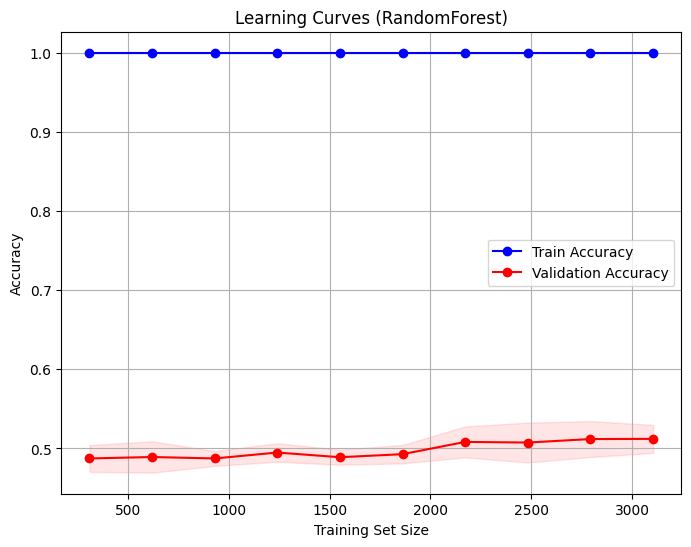

In [ ]:
# Learning Curves для RandomForest
n_splits = 5
class_counts = y.value_counts()
valid_classes = class_counts[class_counts >= n_splits].index
filtered_indices = y[y.isin(valid_classes)].index
X_filtered = X.loc[filtered_indices]
y_filtered = y.loc[filtered_indices]

cv = StratifiedKFold(n_splits=n_splits)
train_sizes, train_scores, test_scores = learning_curve(
    model, X_filtered, y_filtered, cv=cv, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Train Accuracy')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', color='red', label='Validation Accuracy')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')
plt.title('Learning Curves (RandomForest)')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.grid(True)
plt.show()


In [ ]:
# Hyperparameter tuning через GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

rf_classifier = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=rf_classifier,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1
)

X_filtered_final = X_filtered[y_filtered.isin(valid_classes)]
y_filtered_final = y_filtered[y_filtered.isin(valid_classes)]

grid_search.fit(X_filtered_final, y_filtered_final)
print("Best parameters found by GridSearchCV:", grid_search.best_params_)


Best parameters found by GridSearchCV: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 100}



Classification Report for Tuned RandomForestClassifier:
              precision    recall  f1-score   support

           C       0.80      0.79      0.80       302
           E       1.00      0.31      0.48       105
           H       0.76      0.91      0.83       369

    accuracy                           0.78       776
   macro avg       0.85      0.67      0.70       776
weighted avg       0.81      0.78      0.77       776



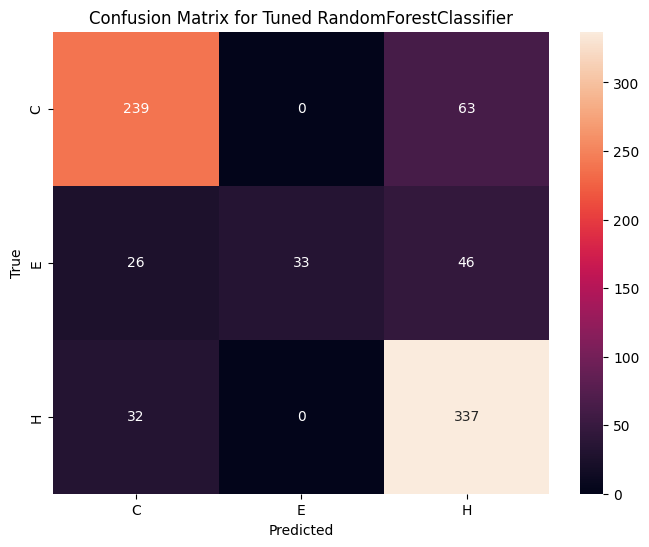

In [ ]:
# Обучение и оценка модели с оптимальными гиперпараметрами
best_rf_model = grid_search.best_estimator_

X_train_tuned, X_test_tuned, y_train_tuned, y_test_tuned = train_test_split(
    X_filtered_final, y_filtered_final, test_size=0.2, random_state=42, stratify=y_filtered_final
)

pred_tuned = best_rf_model.predict(X_test_tuned)
print("\nClassification Report for Tuned RandomForestClassifier:")
print(classification_report(y_test_tuned, pred_tuned))

cm_tuned = confusion_matrix(y_test_tuned, pred_tuned)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', xticklabels=best_rf_model.classes_,
            yticklabels=best_rf_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Tuned RandomForestClassifier")
plt.show()


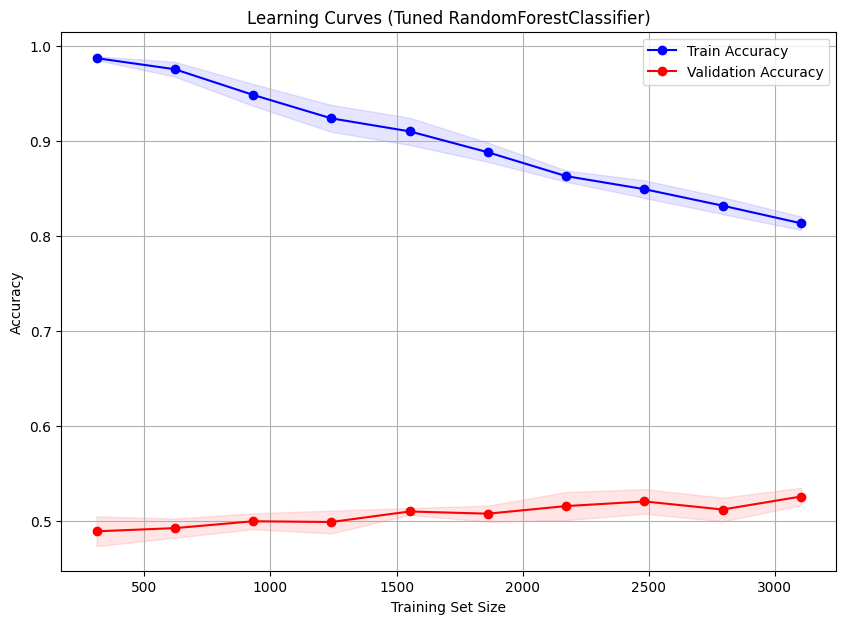

In [ ]:
# Learning Curves для оптимизированной модели
train_sizes, train_scores, test_scores = learning_curve(
    best_rf_model, X_filtered_final, y_filtered_final,
    cv=StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42),
    n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 7))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Train Accuracy')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', color='red', label='Validation Accuracy')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')
plt.title('Learning Curves (Tuned RandomForestClassifier)')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.grid(True)
plt.show()

In [ ]:

# Масштабирование признаков для логистической регрессии
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_tuned)
X_test_scaled = scaler.transform(X_test_tuned)

# Логистическая регрессия с балансировкой классов (multi_class больше не нужен)
lr_model = LogisticRegression(solver='lbfgs', class_weight='balanced',
                              random_state=42, max_iter=2000)
lr_model.fit(X_train_scaled, y_train_tuned)
pred_lr = lr_model.predict(X_test_scaled)
acc_lr = accuracy_score(y_test_tuned, pred_lr)
print("\nLogistic Regression (balanced) Accuracy:", acc_lr)


Logistic Regression (balanced) Accuracy: 0.40850515463917525


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

# 2. XGBoost с балансировкой через sample_weight
# Кодирование строковых меток в целые числа
classes_str = np.unique(y_train_tuned)          # ['C','E','H']
class_to_int = {cls: i for i, cls in enumerate(classes_str)}  # {'C':0, 'E':1, 'H':2}
int_to_class = {i: cls for cls, i in class_to_int.items()}

def plot_roc_curve(y_true, y_score, model_name, classes_str):
    lb = LabelBinarizer()
    y_true_binarized = lb.fit_transform(y_true)

    plt.figure(figsize=(10, 8))
    for i, class_name in enumerate(classes_str):
        fpr, tpr, _ = roc_curve(y_true_binarized[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'ROC curve of class {class_name} (area = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic (ROC) Curve - {model_name}')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

y_train_int = y_train_tuned.map(class_to_int)
y_test_int = y_test_tuned.map(class_to_int)

# Вычисляем веса классов на основе исходных строк (порядок сохраняется)
class_weights = compute_class_weight('balanced', classes=classes_str, y=y_train_tuned)
sample_weights = np.array([class_weights[class_to_int[cls]] for cls in y_train_tuned])

xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=len(classes_str),
                              random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train_tuned, y_train_int, sample_weight=sample_weights)

# Предсказание: возвращает числа, преобразуем обратно в строки
pred_xgb_int = xgb_model.predict(X_test_tuned)
pred_xgb = np.array([int_to_class[i] for i in pred_xgb_int])
acc_xgb = accuracy_score(y_test_tuned, pred_xgb)
print("XGBoost (balanced) Accuracy:", acc_xgb)

XGBoost (balanced) Accuracy: 0.47551546391752575



Сравнение точности моделей:
                                      Model  Accuracy
0                        Tuned RandomForest  0.784794
1        RandomForest (ProtBERT embeddings)  0.660000
2                      RandomForest (k-mer)  0.635309
3                   RandomForest (features)  0.541237
4              XGBoost (balanced, features)  0.475515
5  Logistic Regression (balanced, features)  0.408505


/tmp/ipython-input-1141/140411569.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=acc_df, palette='viridis')


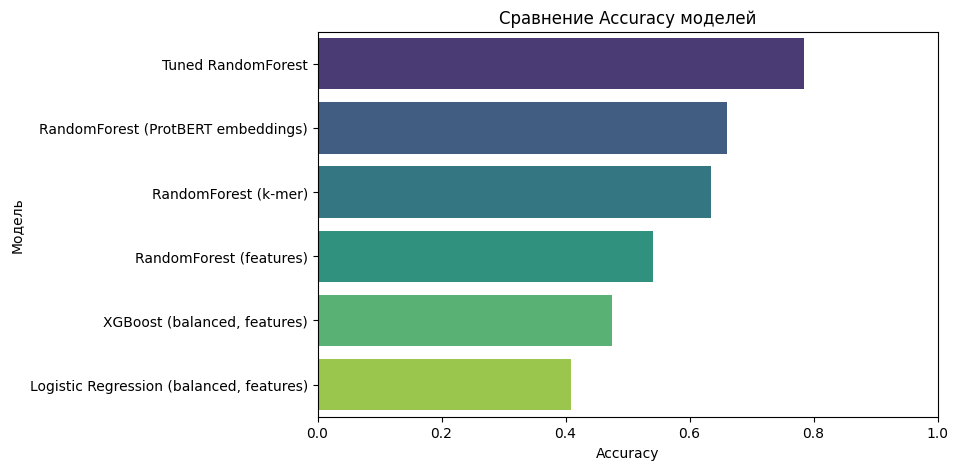

In [ ]:
acc_feature_rf = accuracy_score(y_test_feat, pred_feat)
acc_kmer_rf = accuracy_score(y_test_kmer, pred_kmer)
acc_embed_rf = accuracy_score(y_test_embed, pred_embed)
acc_tuned_rf = accuracy_score(y_test_tuned, pred_tuned)

acc_df = pd.DataFrame({
    'Model': [
        'RandomForest (features)',
        'RandomForest (k-mer)',
        'RandomForest (ProtBERT embeddings)',
        'Tuned RandomForest',
        'Logistic Regression (balanced, features)',
        'XGBoost (balanced, features)'
    ],
    'Accuracy': [
        acc_feature_rf,
        acc_kmer_rf,
        acc_embed_rf,
        acc_tuned_rf,
        acc_lr,
        acc_xgb
    ]
})

acc_df = acc_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
print("\nСравнение точности моделей:")
print(acc_df)

plt.figure(figsize=(8,5))
sns.barplot(x='Accuracy', y='Model', data=acc_df, palette='viridis')
plt.xlim(0,1)
plt.title('Сравнение Accuracy моделей')
plt.xlabel('Accuracy')
plt.ylabel('Модель')
plt.show()